# 01 Data Inventory and Outage Exploration

## Project: PG&E-Style Utility Operations & Meter-to-Cash Analytics

This notebook begins the data exploration phase of a utility operations and billing modernization project. The goal is to use real public California utility datasets to understand current outage activity, county-level outage impacts, electricity consumption patterns, and utility-level demand. These datasets will later support a broader Meter-to-Cash analytics system involving outage impact analysis, billing exception logic, data quality checks, migration readiness reporting, and Power BI dashboard development.

In this notebook, I will:

1. Load the raw outage and electricity consumption datasets.
2. Inspect each dataset’s structure, column names, dimensions, and data quality.
3. Identify which fields can be used to connect outage activity with county and utility-level electricity consumption.
4. Create initial summaries of outage incidents by utility, county, cause, outage type, and impacted customers.
5. Document cleaning decisions before building processed datasets for analysis and dashboarding.

The purpose of this first notebook is to establish a clean, reproducible understanding of the raw data sources.

## Data Sources

The initial raw datasets include:

- **California Power Outage Incidents**: incident-level outage records from California public utility outage maps.
- **California Power Outages by County**: county-level outage impact summary.
- **CEC Electricity Consumption by County**: monthly electricity consumption by California county and sector.
- **CEC Electricity Consumption by Utility**: monthly electricity consumption by utility/entity and sector.
- **Power Outage Areas GeoJSON**: outage area geometry data for potential mapping use later in the project.

## 1. Import Libraries and Define File Paths

This section imports the required Python libraries and defines the raw data directory. 

In [2]:
import pandas as pd
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

# Define project paths
RAW_DIR = Path("../raw")

# Confirm available raw files
raw_files = sorted([file.name for file in RAW_DIR.iterdir()])
raw_files

['cec_electricity_county_monthly.csv',
 'cec_electricity_utility_monthly.csv',
 'power_outage_areas.geojson',
 'power_outages_by_county.csv',
 'power_outages_by_incidents.csv']

## 2. Load Raw Datasets

This section loads the four CSV datasets that will be used in the first stage of analysis. The GeoJSON outage area file is left for a later mapping step because the initial goal is to inspect tabular outage and electricity consumption data.

In [3]:
# Load raw CSV datasets
outage_county = pd.read_csv(RAW_DIR / "power_outages_by_county.csv")
outage_incidents = pd.read_csv(RAW_DIR / "power_outages_by_incidents.csv")
cec_county = pd.read_csv(RAW_DIR / "cec_electricity_county_monthly.csv")
cec_utility = pd.read_csv(RAW_DIR / "cec_electricity_utility_monthly.csv")

# Print dataset dimensions
print("Outage county:", outage_county.shape)
print("Outage incidents:", outage_incidents.shape)
print("CEC county:", cec_county.shape)
print("CEC utility:", cec_utility.shape)

Outage county: (47, 11)
Outage incidents: (258, 15)
CEC county: (82558, 7)
CEC utility: (73647, 12)


C:\Users\Chris\AppData\Local\Temp\ipykernel_26220\997944357.py:5: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  cec_utility = pd.read_csv(RAW_DIR / "cec_electricity_utility_monthly.csv")


## 3. Inspect Dataset Columns and Sample Records

This section reviews column names and sample records for each dataset. This helps identify naming inconsistencies, useful join keys, date fields, numeric fields, and potential data quality issues before cleaning.

In [4]:
# Inspect column names for each dataset
datasets = {
    "outage_county": outage_county,
    "outage_incidents": outage_incidents,
    "cec_county": cec_county,
    "cec_utility": cec_utility
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * len(name))
    print(df.columns.tolist())


outage_county
-------------
['OBJECTID', 'NAME', 'Region', 'Administration Region', 'Mutual Aid Region', 'Number Impacted Customers', 'Number Incidents', 'Impacted Customers (Planned Outage)', 'Impacted Customers (Non-Planned Outage)', 'Shape__Area', 'Shape__Length']

outage_incidents
----------------
['OBJECTID', 'UtilityCompany', 'Start Date/Time', 'Estimated Restoration Date/Time', 'Cause', 'Impacted Customers', 'County', 'Outage Status', 'Outage Type', 'GlobalID', 'OutageTypeColor', 'OutageStatusColor', 'Indicent ID', 'x', 'y']

cec_county
----------
['YEAR', 'MONTH', 'COUNTY_NUM', 'COUNTY_NAME', 'SECTOR', 'RNR', 'GWH']

cec_utility
-----------
['YEAR', 'MONTH', 'PLANNING_AREA', 'AGENCY_NAME', 'AGENCY_TYPE', 'SECTOR', 'RNR', 'GWH', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']


### Initial Data Profiling Notes

- `outage_county` is a county-level outage summary dataset, with one row per county and fields for impacted customers, incident counts, and geographic shape attributes.
- `outage_incidents` is an incident-level outage dataset, with one row per outage incident and fields for utility company, start time, estimated restoration time, cause, impacted customers, outage status, outage type, county, and coordinates.
- `cec_county` is a monthly electricity consumption dataset by county and sector, with consumption measured in GWh.
- `cec_utility` is a monthly electricity consumption dataset by utility/entity and sector. It includes several unnamed columns that appear to be blank export artifacts and should be removed during cleaning.


## 4. Standardize Column Names

The raw datasets use a mix of capitalization, spaces, punctuation, and unused export columns. This section converts the column names into consistent `snake_case` format and removes blank columns from the CEC utility dataset.

In [5]:
# Create working copies so the raw imported data remains unchanged
outage_county_clean = outage_county.copy()
outage_incidents_clean = outage_incidents.copy()
cec_county_clean = cec_county.copy()
cec_utility_clean = cec_utility.copy()

# Rename outage county columns
outage_county_clean = outage_county_clean.rename(columns={
    "OBJECTID": "object_id",
    "NAME": "county",
    "Region": "region",
    "Administration Region": "administration_region",
    "Mutual Aid Region": "mutual_aid_region",
    "Number Impacted Customers": "number_impacted_customers",
    "Number Incidents": "number_incidents",
    "Impacted Customers (Planned Outage)": "impacted_customers_planned",
    "Impacted Customers (Non-Planned Outage)": "impacted_customers_unplanned",
    "Shape__Area": "shape_area",
    "Shape__Length": "shape_length"
})

# Rename outage incident columns
outage_incidents_clean = outage_incidents_clean.rename(columns={
    "OBJECTID": "object_id",
    "UtilityCompany": "utility_company",
    "Start Date/Time": "start_datetime",
    "Estimated Restoration Date/Time": "estimated_restoration_datetime",
    "Cause": "cause",
    "Impacted Customers": "impacted_customers",
    "County": "county",
    "Outage Status": "outage_status",
    "Outage Type": "outage_type",
    "GlobalID": "global_id",
    "OutageTypeColor": "outage_type_color",
    "OutageStatusColor": "outage_status_color",
    "Indicent ID": "incident_id",
    "x": "x",
    "y": "y"
})

# Rename CEC county columns
cec_county_clean = cec_county_clean.rename(columns={
    "YEAR": "year",
    "MONTH": "month",
    "COUNTY_NUM": "county_num",
    "COUNTY_NAME": "county",
    "SECTOR": "sector",
    "RNR": "residential_nonresidential",
    "GWH": "gwh"
})

# Remove blank export columns from the CEC utility dataset
cec_utility_clean = cec_utility_clean.loc[:, ~cec_utility_clean.columns.str.contains("^Unnamed")]

# Rename CEC utility columns
cec_utility_clean = cec_utility_clean.rename(columns={
    "YEAR": "year",
    "MONTH": "month",
    "PLANNING_AREA": "planning_area",
    "AGENCY_NAME": "agency_name",
    "AGENCY_TYPE": "agency_type",
    "SECTOR": "sector",
    "RNR": "residential_nonresidential",
    "GWH": "gwh"
})

# Confirm cleaned column names
cleaned_datasets = {
    "outage_county_clean": outage_county_clean,
    "outage_incidents_clean": outage_incidents_clean,
    "cec_county_clean": cec_county_clean,
    "cec_utility_clean": cec_utility_clean
}

for name, df in cleaned_datasets.items():
    print(f"\n{name}")
    print("-" * len(name))
    print(df.columns.tolist())


outage_county_clean
-------------------
['object_id', 'county', 'region', 'administration_region', 'mutual_aid_region', 'number_impacted_customers', 'number_incidents', 'impacted_customers_planned', 'impacted_customers_unplanned', 'shape_area', 'shape_length']

outage_incidents_clean
----------------------
['object_id', 'utility_company', 'start_datetime', 'estimated_restoration_datetime', 'cause', 'impacted_customers', 'county', 'outage_status', 'outage_type', 'global_id', 'outage_type_color', 'outage_status_color', 'incident_id', 'x', 'y']

cec_county_clean
----------------
['year', 'month', 'county_num', 'county', 'sector', 'residential_nonresidential', 'gwh']

cec_utility_clean
-----------------
['year', 'month', 'planning_area', 'agency_name', 'agency_type', 'sector', 'residential_nonresidential', 'gwh']


## 5. Review Data Types and Missing Values

After standardizing column names, the next step is to inspect data types and missing values. This helps identify which fields need conversion, such as dates, numeric outage counts, impacted customer totals, and electricity consumption values.

In [6]:
# Review data types and missing values for each cleaned dataset
for name, df in cleaned_datasets.items():
    print(f"\n{name}")
    print("-" * len(name))
    
    profile = pd.DataFrame({
        "dtype": df.dtypes,
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique()
    })
    
    display(profile)


outage_county_clean
-------------------


,dtype,missing_count,missing_pct,unique_values
object_id,int64,0,0.0,47
county,object,0,0.0,47
region,int64,0,0.0,10
administration_region,object,0,0.0,3
mutual_aid_region,int64,0,0.0,6
number_impacted_customers,int64,0,0.0,36
number_incidents,int64,0,0.0,14
impacted_customers_planned,int64,0,0.0,31
impacted_customers_unplanned,int64,0,0.0,28
shape_area,float64,0,0.0,47



outage_incidents_clean
----------------------


,dtype,missing_count,missing_pct,unique_values
object_id,int64,0,0.00,258
utility_company,object,0,0.00,4
start_datetime,object,1,0.39,221
estimated_restoration_datetime,object,20,7.75,51
cause,object,56,21.71,24
impacted_customers,int64,0,0.00,78
county,object,0,0.00,47
outage_status,object,0,0.00,1
outage_type,object,0,0.00,2
global_id,object,0,0.00,258



cec_county_clean
----------------


,dtype,missing_count,missing_pct,unique_values
year,int64,0,0.0,17
month,object,0,0.0,12
county_num,int64,0,0.0,58
county,object,0,0.0,58
sector,object,0,0.0,7
residential_nonresidential,object,0,0.0,2
gwh,float64,0,0.0,82004



cec_utility_clean
-----------------


,dtype,missing_count,missing_pct,unique_values
year,int64,0,0.0,17
month,object,0,0.0,12
planning_area,object,0,0.0,10
agency_name,object,0,0.0,68
agency_type,object,0,0.0,6
sector,object,0,0.0,7
residential_nonresidential,object,0,0.0,2
gwh,float64,0,0.0,69083


### Data Profiling Findings

The initial data quality review shows that the datasets are generally clean and usable for analysis.

Key findings:

- The county-level outage dataset has no missing values and already contains numeric fields for impacted customers and incident counts.
- The outage incident dataset has some missing values in `start_datetime`, `estimated_restoration_datetime`, and `cause`, which is expected for a live operational outage feed.
- The `outage_status_color` field is fully missing and does not add analytical value, so it will be removed.
- The outage incident dataset already contains numeric impacted customer counts.
- The CEC county and utility consumption datasets have no missing values, and `gwh` is already stored as a numeric field.
- Date-related fields still need cleaning because outage dates and CEC month/year fields are currently not in a unified date format.

Based on this review, the next cleaning steps are to remove unused fields, convert date columns, standardize text fields, and create analysis-ready month/date variables.

## 6. Clean Dates, Drop Unused Fields, and Standardize Text Values

This section performs the first round of data cleaning. The main goals are to convert date fields into proper datetime format, remove columns that do not support the analysis, and standardize key text fields such as county names, utility names, sectors, outage status, and outage type.

In [8]:
# Drop columns that do not add analytical value
outage_incidents_clean = outage_incidents_clean.drop(
    columns=["outage_status_color"],
    errors="ignore"
)

# Convert outage date fields to datetime using the source date format
outage_incidents_clean["start_datetime"] = pd.to_datetime(
    outage_incidents_clean["start_datetime"],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

outage_incidents_clean["estimated_restoration_datetime"] = pd.to_datetime(
    outage_incidents_clean["estimated_restoration_datetime"],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

# Standardize county names across outage and consumption datasets
outage_county_clean["county"] = outage_county_clean["county"].str.upper().str.strip()
outage_incidents_clean["county"] = outage_incidents_clean["county"].str.upper().str.strip()
cec_county_clean["county"] = cec_county_clean["county"].str.upper().str.strip()

# Standardize key categorical fields
outage_incidents_clean["utility_company"] = (
    outage_incidents_clean["utility_company"]
    .str.upper()
    .str.strip()
)

outage_incidents_clean["outage_status"] = (
    outage_incidents_clean["outage_status"]
    .str.title()
    .str.strip()
)

outage_incidents_clean["outage_type"] = (
    outage_incidents_clean["outage_type"]
    .str.title()
    .str.strip()
)

cec_county_clean["sector"] = (
    cec_county_clean["sector"]
    .str.title()
    .str.strip()
)

cec_utility_clean["sector"] = (
    cec_utility_clean["sector"]
    .str.title()
    .str.strip()
)

cec_utility_clean["agency_name"] = (
    cec_utility_clean["agency_name"]
    .str.upper()
    .str.strip()
)

# Create outage date features
outage_incidents_clean["start_date"] = outage_incidents_clean["start_datetime"].dt.date
outage_incidents_clean["start_year"] = outage_incidents_clean["start_datetime"].dt.year
outage_incidents_clean["start_month"] = outage_incidents_clean["start_datetime"].dt.month
outage_incidents_clean["start_hour"] = outage_incidents_clean["start_datetime"].dt.hour

# Calculate estimated restoration duration in hours
outage_incidents_clean["estimated_restoration_hours"] = (
    outage_incidents_clean["estimated_restoration_datetime"]
    - outage_incidents_clean["start_datetime"]
).dt.total_seconds() / 3600

# Review cleaned outage incident fields
outage_incidents_clean[
    [
        "utility_company",
        "start_datetime",
        "estimated_restoration_datetime",
        "estimated_restoration_hours",
        "cause",
        "impacted_customers",
        "county",
        "outage_status",
        "outage_type"
    ]
].head()

,utility_company,start_datetime,estimated_restoration_datetime,estimated_restoration_hours,cause,impacted_customers,county,outage_status,outage_type
0,SDGE,2026-06-10 14:30:00,2026-06-10 19:30:00,5.000000,The cause of the outage is unknown and still u...,2,SAN DIEGO,Active,Not Planned
1,SDGE,2026-06-10 14:44:00,2026-06-10 23:00:00,8.266667,A vehicle has come into contact with our elect...,28,SAN DIEGO,Active,Not Planned
2,SDGE,2026-06-10 18:13:00,2026-06-10 23:00:00,4.783333,Upgrading the electric system in your area req...,58,SAN DIEGO,Active,Planned
3,SDGE,2026-06-10 16:28:00,2026-06-11 00:00:00,7.533333,Upgrading the electric system in your area req...,2,SAN DIEGO,Active,Planned
4,SDGE,2026-06-10 17:31:00,2026-06-10 22:00:00,4.483333,Upgrading the electric system in your area req...,2,SAN DIEGO,Active,Planned


### Date Conversion Validation

The outage incident date fields were converted from raw text into datetime fields. This check confirms that the converted fields have the correct data types and shows how many records could not be parsed.

In [9]:
# Confirm date conversion results
date_validation = pd.DataFrame({
    "dtype": outage_incidents_clean[
        ["start_datetime", "estimated_restoration_datetime", "estimated_restoration_hours"]
    ].dtypes,
    "missing_count": outage_incidents_clean[
        ["start_datetime", "estimated_restoration_datetime", "estimated_restoration_hours"]
    ].isna().sum(),
    "missing_pct": (
        outage_incidents_clean[
            ["start_datetime", "estimated_restoration_datetime", "estimated_restoration_hours"]
        ].isna().mean() * 100
    ).round(2)
})

date_validation

,dtype,missing_count,missing_pct
start_datetime,datetime64[ns],1,0.39
estimated_restoration_datetime,datetime64[ns],20,7.75
estimated_restoration_hours,float64,21,8.14


## 7. Outage Incident Summary by Utility

This section creates the first operational summary table from the incident-level outage data. The goal is to understand which utility companies appear in the current outage feed, how many outage incidents each has, how many customers are impacted, and how restoration time varies across utilities.

In [10]:
# Summarize outage incidents by utility company
utility_summary = (
    outage_incidents_clean
    .groupby("utility_company", dropna=False)
    .agg(
        outage_incidents=("incident_id", "nunique"),
        total_impacted_customers=("impacted_customers", "sum"),
        avg_impacted_customers=("impacted_customers", "mean"),
        median_impacted_customers=("impacted_customers", "median"),
        avg_estimated_restoration_hours=("estimated_restoration_hours", "mean"),
        max_estimated_restoration_hours=("estimated_restoration_hours", "max")
    )
    .reset_index()
    .sort_values("total_impacted_customers", ascending=False)
)

# Round numeric fields for readability
utility_summary["avg_impacted_customers"] = utility_summary["avg_impacted_customers"].round(1)
utility_summary["avg_estimated_restoration_hours"] = utility_summary["avg_estimated_restoration_hours"].round(2)
utility_summary["max_estimated_restoration_hours"] = utility_summary["max_estimated_restoration_hours"].round(2)

utility_summary

,utility_company,outage_incidents,total_impacted_customers,avg_impacted_customers,median_impacted_customers,avg_estimated_restoration_hours,max_estimated_restoration_hours
0,PGE,172,8953,52.1,3.0,7.38,49.42
1,SCE,62,8095,130.6,30.5,13.94,22.39
3,SMUD,6,302,50.3,7.5,3.71,7.22
2,SDGE,18,167,9.3,1.5,5.63,9.00


### Utility-Level Outage Summary Findings

The current outage incident feed includes four utility companies: PGE, SCE, SDGE, and SMUD.

Key observations:

- PGE has the highest number of outage incidents in the current feed, with 172 unique incidents.
- PGE also has the highest total impacted customers, with 8,953 impacted customers.
- SCE has fewer incidents than PGE, but a higher average number of impacted customers per incident.
- PGE’s median impacted customers per incident is low relative to its average, which suggests that many incidents are small while a smaller number of larger incidents drive total customer impact.
- SCE has the highest average estimated restoration time among the listed utilities.

These findings are based on the current outage snapshot and should not be interpreted as long-term reliability performance because the dataset does not contain historical outage records.

## 8. Create PG&E-Focused Outage Subset

Because this project is designed around PG&E-style utility operations and IT modernization use cases, this section creates a PG&E-only outage incident subset for deeper analysis.

In [11]:
# Create PG&E-only outage incident subset
pge_outages = outage_incidents_clean[
    outage_incidents_clean["utility_company"] == "PGE"
].copy()

print("PG&E outage incidents:", pge_outages.shape)

pge_outages[
    [
        "incident_id",
        "start_datetime",
        "estimated_restoration_datetime",
        "estimated_restoration_hours",
        "cause",
        "impacted_customers",
        "county",
        "outage_status",
        "outage_type"
    ]
].head()

PG&E outage incidents: (172, 19)


,incident_id,start_datetime,estimated_restoration_datetime,estimated_restoration_hours,cause,impacted_customers,county,outage_status,outage_type
86,274224,2026-06-08 20:35:00,2026-06-10 22:00:00,49.416667,POLE FIRE,25,SOLANO,Active,Not Planned
87,274235,2026-06-08 20:35:00,2026-06-10 22:00:00,49.416667,POLE FIRE,7,SOLANO,Active,Not Planned
88,274764,2026-06-09 11:06:29,2026-06-09 12:00:00,0.891944,PLNND SHUTDOWN,1,SAN MATEO,Active,Planned
89,275014,2026-06-09 15:31:00,2026-06-09 23:30:00,7.983333,PLNND SHUTDOWN,6,EL DORADO,Active,Planned
90,275057,2026-06-09 16:13:49,2026-06-09 19:30:00,3.269722,PLNND SHUTDOWN,32,SAN MATEO,Active,Planned


## 9. PG&E Outage Summary by County

This section summarizes PG&E outage incidents by county. The goal is to identify where the current outage impact is concentrated and which counties have the highest number of incidents, impacted customers, and estimated restoration times.

In [12]:
# Summarize PG&E outage incidents by county
pge_county_summary = (
    pge_outages
    .groupby("county", dropna=False)
    .agg(
        outage_incidents=("incident_id", "nunique"),
        total_impacted_customers=("impacted_customers", "sum"),
        avg_impacted_customers=("impacted_customers", "mean"),
        median_impacted_customers=("impacted_customers", "median"),
        avg_estimated_restoration_hours=("estimated_restoration_hours", "mean"),
        max_estimated_restoration_hours=("estimated_restoration_hours", "max")
    )
    .reset_index()
    .sort_values("total_impacted_customers", ascending=False)
)

# Round numeric columns for readability
pge_county_summary["avg_impacted_customers"] = pge_county_summary["avg_impacted_customers"].round(1)
pge_county_summary["avg_estimated_restoration_hours"] = pge_county_summary["avg_estimated_restoration_hours"].round(2)
pge_county_summary["max_estimated_restoration_hours"] = pge_county_summary["max_estimated_restoration_hours"].round(2)

pge_county_summary.head(15)

,county,outage_incidents,total_impacted_customers,avg_impacted_customers,median_impacted_customers,avg_estimated_restoration_hours,max_estimated_restoration_hours
5,CONTRA COSTA,6,4141,690.2,18.0,6.59,7.88
8,GLENN,5,1458,291.6,319.0,NaN,NaN
28,SANTA CLARA,21,933,44.4,3.0,8.09,29.90
0,ALAMEDA,15,476,31.7,13.0,8.70,24.25
26,SAN MATEO,16,434,27.1,9.5,6.23,10.05
14,MARIN,3,327,109.0,1.0,8.60,10.22
10,KERN,4,220,55.0,8.0,6.73,9.94
21,PLACER,2,202,101.0,101.0,6.81,7.89
23,SAN FRANCISCO,6,100,16.7,1.0,6.37,9.47
20,NEVADA,3,84,28.0,8.0,6.44,7.97


### PG&E County-Level Outage Findings

The PG&E-focused outage subset shows that current customer impact is not evenly distributed across counties.

Key observations:

- Contra Costa has the highest total impacted customer count in the current PG&E outage feed.
- Santa Clara has the highest number of PG&E outage incidents among the top impacted counties, but its average impacted customers per incident is lower than Contra Costa and Glenn.
- Glenn has a high customer impact despite relatively few incidents, suggesting a smaller number of larger-impact outages.
- Several counties have missing estimated restoration duration values because not every outage incident includes an estimated restoration timestamp.
- These county-level summaries can support operational reporting by identifying where outage impact is concentrated and where restoration-time data completeness may need improvement.

Because this dataset is a current outage snapshot, these results should be interpreted as current operational conditions rather than long-term reliability performance.

## 10. PG&E Outage Summary by Outage Type

This section compares planned and unplanned PG&E outages. This is useful for separating scheduled maintenance activity from unexpected outages, which may have different operational causes, customer communication requirements, and restoration expectations.

In [13]:
# Summarize PG&E outages by outage type
pge_outage_type_summary = (
    pge_outages
    .groupby("outage_type", dropna=False)
    .agg(
        outage_incidents=("incident_id", "nunique"),
        total_impacted_customers=("impacted_customers", "sum"),
        avg_impacted_customers=("impacted_customers", "mean"),
        median_impacted_customers=("impacted_customers", "median"),
        avg_estimated_restoration_hours=("estimated_restoration_hours", "mean")
    )
    .reset_index()
    .sort_values("total_impacted_customers", ascending=False)
)

pge_outage_type_summary["avg_impacted_customers"] = pge_outage_type_summary["avg_impacted_customers"].round(1)
pge_outage_type_summary["avg_estimated_restoration_hours"] = pge_outage_type_summary["avg_estimated_restoration_hours"].round(2)

pge_outage_type_summary

,outage_type,outage_incidents,total_impacted_customers,avg_impacted_customers,median_impacted_customers,avg_estimated_restoration_hours
0,Not Planned,95,7670,80.7,1.0,7.95
1,Planned,77,1283,16.7,5.0,6.82


In [14]:
# Inspect distribution of impacted customers by outage type
pge_outages.groupby("outage_type")["impacted_customers"].describe()

,count,mean,std,min,25%,50%,75%,max
outage_type,,,,,,,,
Not Planned,95.0,80.736842,428.313099,1.0,1.0,1.0,15.5,4062.0
Planned,77.0,16.662338,39.564275,1.0,2.0,5.0,17.0,325.0


In [15]:
# Review the smallest and largest unplanned outage incidents
pge_unplanned = pge_outages[pge_outages["outage_type"] == "Not Planned"].copy()

display(
    pge_unplanned["impacted_customers"]
    .value_counts()
    .sort_index()
    .head(15)
)

display(
    pge_unplanned[
        ["incident_id", "county", "cause", "impacted_customers", "estimated_restoration_hours"]
    ]
    .sort_values("impacted_customers", ascending=False)
    .head(10)
)

impacted_customers
1     57
3      1
4      5
7      3
9      2
12     1
15     2
16     1
17     1
18     1
19     1
21     3
25     1
27     2
49     1
Name: count, dtype: int64

,incident_id,county,cause,impacted_customers,estimated_restoration_hours
222,276313,CONTRA COSTA,NaN,4062,7.430000
212,276284,SANTA CLARA,PATROLLING,761,2.800000
251,276359,GLENN,PUBLIC SAFETY,566,NaN
250,276358,GLENN,PUBLIC SAFETY,409,NaN
248,276356,GLENN,PUBLIC SAFETY,319,NaN
245,276353,KERN,NaN,203,NaN
194,276237,PLACER,PATROLLING,199,5.733333
98,275848,ALAMEDA,NaN,182,7.784444
148,276032,SAN MATEO,EMERG REPAIRS,182,10.050000
242,276350,GLENN,PUBLIC SAFETY,157,NaN


### Largest Outage Incident Findings

The largest PG&E outage incidents explain why average impacted customers is much higher than the median.

The current snapshot shows that many unplanned outages affect only one customer, but the largest incident affects more than 4,000 customers in Contra Costa County. This creates a highly skewed distribution where a small number of major incidents drive most of the customer impact.

This distinction is operationally important because outage incident count reflects workload volume, while impacted customer count better reflects customer impact and prioritization risk.

## 11. PG&E Outage Summary by Cause

This section summarizes PG&E outage incidents by listed cause. Cause-level analysis helps identify whether current outage activity is driven by planned work, repairs, patrol activity, public safety actions, equipment issues, or unknown causes.

In [16]:
# Replace missing causes with a readable category
pge_outages["cause_clean"] = (
    pge_outages["cause"]
    .fillna("UNKNOWN / NOT PROVIDED")
    .str.upper()
    .str.strip()
)

# Summarize PG&E outages by cause
pge_cause_summary = (
    pge_outages
    .groupby("cause_clean", dropna=False)
    .agg(
        outage_incidents=("incident_id", "nunique"),
        total_impacted_customers=("impacted_customers", "sum"),
        avg_impacted_customers=("impacted_customers", "mean"),
        median_impacted_customers=("impacted_customers", "median"),
        avg_estimated_restoration_hours=("estimated_restoration_hours", "mean")
    )
    .reset_index()
    .sort_values("total_impacted_customers", ascending=False)
)

pge_cause_summary["avg_impacted_customers"] = pge_cause_summary["avg_impacted_customers"].round(1)
pge_cause_summary["avg_estimated_restoration_hours"] = pge_cause_summary["avg_estimated_restoration_hours"].round(2)

pge_cause_summary.head(15)

,cause_clean,outage_incidents,total_impacted_customers,avg_impacted_customers,median_impacted_customers,avg_estimated_restoration_hours
12,UNKNOWN / NOT PROVIDED,56,4713,84.2,1.0,6.33
7,PUBLIC SAFETY,6,1507,251.2,238.0,NaN
5,PLNND SHUTDOWN,77,1283,16.7,5.0,6.82
4,PATROLLING,16,1000,62.5,1.0,6.00
3,EMERG REPAIRS,4,209,52.2,13.0,6.10
1,BRKN UG EQUIPMNT,3,119,39.7,21.0,13.47
6,POLE FIRE,2,32,16.0,16.0,49.42
10,THRD PARTY,1,27,27.0,27.0,6.88
11,TREE CONTACT,1,21,21.0,21.0,8.50
0,AWAITING INVESTIGATION,2,20,10.0,10.0,3.46


### Cause-Level Outage Findings

Cause-level analysis shows that the largest share of impacted customers is associated with outages where the cause is unknown or not provided. This is analytically important because missing cause information limits root-cause analysis and makes it harder to classify operational drivers.

Key observations:

- `UNKNOWN / NOT PROVIDED` has the highest total impacted customer count, driven by a small number of large-impact incidents.
- `PUBLIC SAFETY` has relatively few incidents but a high median impacted customer count, suggesting larger typical customer impact within that category.
- `PLNND SHUTDOWN` appears to represent planned shutdown activity and accounts for the largest number of incidents.
- Several operational cause categories appear abbreviated, such as `BRKN UG EQUIPMNT`, `DAMGE UG CABLE`, and `REPLCE TXFMR`, which should be standardized or mapped to readable business categories in a later cleaning step.

This finding creates a useful data quality and business process opportunity: standardizing outage cause categories would improve reporting, root-cause analysis, and stakeholder communication.

## 12. Map Outage Causes to Business-Friendly Categories

Raw outage causes include missing values, abbreviations, and operational shorthand. This section maps detailed cause labels into broader business-friendly categories that can be used in dashboards and executive reporting.

In [17]:
def map_cause_category(cause):
    """
    Map raw outage cause labels into broader business-friendly categories.
    """
    if pd.isna(cause):
        return "Unknown / Not Provided"
    
    cause = str(cause).upper().strip()
    
    if cause in ["UNKNOWN / NOT PROVIDED"]:
        return "Unknown / Not Provided"
    elif "PLNND" in cause or "PLANNED" in cause or "SHUTDOWN" in cause:
        return "Planned Work"
    elif "PUBLIC SAFETY" in cause:
        return "Public Safety"
    elif "PATROLLING" in cause:
        return "Inspection / Patrol"
    elif "REPAIR" in cause or "REPAIRS" in cause or "REPLCE" in cause or "REPLACE" in cause:
        return "Repairs / Replacement"
    elif "UG" in cause or "CABLE" in cause or "EQUIP" in cause or "TXFMR" in cause:
        return "Equipment / Underground"
    elif "POLE FIRE" in cause or "TREE" in cause or "THRD PARTY" in cause or "THIRD PARTY" in cause:
        return "External / Environmental"
    elif "INVESTIGATION" in cause:
        return "Under Investigation"
    else:
        return "Other"
    
pge_outages["cause_category"] = pge_outages["cause_clean"].apply(map_cause_category)

pge_cause_category_summary = (
    pge_outages
    .groupby("cause_category")
    .agg(
        outage_incidents=("incident_id", "nunique"),
        total_impacted_customers=("impacted_customers", "sum"),
        avg_impacted_customers=("impacted_customers", "mean"),
        median_impacted_customers=("impacted_customers", "median"),
        avg_estimated_restoration_hours=("estimated_restoration_hours", "mean")
    )
    .reset_index()
    .sort_values("total_impacted_customers", ascending=False)
)

pge_cause_category_summary["avg_impacted_customers"] = pge_cause_category_summary["avg_impacted_customers"].round(1)
pge_cause_category_summary["avg_estimated_restoration_hours"] = pge_cause_category_summary["avg_estimated_restoration_hours"].round(2)

pge_cause_category_summary

,cause_category,outage_incidents,total_impacted_customers,avg_impacted_customers,median_impacted_customers,avg_estimated_restoration_hours
7,Unknown / Not Provided,56,4713,84.2,1.0,6.33
4,Public Safety,6,1507,251.2,238.0,NaN
3,Planned Work,77,1283,16.7,5.0,6.82
2,Inspection / Patrol,16,1000,62.5,1.0,6.00
5,Repairs / Replacement,6,214,35.7,6.5,6.24
0,Equipment / Underground,5,136,27.2,16.0,14.92
1,External / Environmental,4,80,20.0,23.0,28.56
6,Under Investigation,2,20,10.0,10.0,3.46


### Cause Category Findings

Mapping raw outage causes into broader business-friendly categories makes the outage data easier to interpret for operational reporting.

Key observations:

- `Unknown / Not Provided` remains the largest category by total impacted customers, which highlights a data completeness issue in the current outage feed.
- `Public Safety` has relatively few incidents but the highest average and median impacted customers, suggesting larger typical customer impact.
- `Planned Work` has the highest number of incidents, but lower average customer impact than public safety and unknown-cause outages.
- `Inspection / Patrol` represents a meaningful share of impacted customers and may reflect field investigation or inspection-related activity.
- Equipment, underground, external, environmental, and investigation categories have lower total customer impact in the current snapshot but remain useful for operational classification.

This cause category mapping could support dashboard filters, executive summaries, root-cause reporting, and data quality improvement efforts.

## 13. Prepare County-Level Electricity Consumption Data

This section prepares the CEC county-level electricity consumption dataset for analysis. The goal is to create monthly county-level consumption summaries that can later be joined to outage data by county.

In [18]:
# Review available years and sectors in the CEC county dataset
print("Year range:", cec_county_clean["year"].min(), "-", cec_county_clean["year"].max())
print("\nSectors:")
print(sorted(cec_county_clean["sector"].unique()))

print("\nResidential / Non-Residential categories:")
print(sorted(cec_county_clean["residential_nonresidential"].unique()))

Year range: 2008 - 2024

Sectors:
['Agriculture And Water Pumping', 'Commercial', 'Industrial', 'Mining', 'Residential', 'Streetlighting', 'Transportation, Communications, & Utilities']

Residential / Non-Residential categories:
['Non-Residential', 'Residential']


### County Consumption Preparation Notes

The CEC county electricity consumption dataset provides monthly electricity consumption from 2008 through 2024. It includes sector-level consumption by county, which can be aggregated to create county-level demand context.

For this project, the first consumption summary will aggregate GWh by county, year, and month across all sectors. This creates a monthly county demand table that can later be joined to outage data by county.

In [19]:
# Create monthly county-level electricity consumption summary
cec_county_monthly_summary = (
    cec_county_clean
    .groupby(["county", "year", "month"], as_index=False)
    .agg(
        total_gwh=("gwh", "sum"),
        residential_gwh=(
            "gwh",
            lambda x: x[
                cec_county_clean.loc[x.index, "residential_nonresidential"] == "Residential"
            ].sum()
        ),
        nonresidential_gwh=(
            "gwh",
            lambda x: x[
                cec_county_clean.loc[x.index, "residential_nonresidential"] == "Non-Residential"
            ].sum()
        )
    )
)

# Review summary table
print("CEC county monthly summary:", cec_county_monthly_summary.shape)
cec_county_monthly_summary.head()

CEC county monthly summary: (11832, 6)


,county,year,month,total_gwh,residential_gwh,nonresidential_gwh
0,ALAMEDA,2008,April,905.672467,234.213011,671.459456
1,ALAMEDA,2008,August,910.288820,223.824474,686.464347
2,ALAMEDA,2008,December,926.940191,296.165607,630.774584
3,ALAMEDA,2008,February,971.517644,267.267005,704.250639
4,ALAMEDA,2008,January,1106.703849,328.785745,777.918103


### Create Monthly Date Field

The CEC county consumption data stores year and month as separate fields. This section combines them into a single `month_start_date` field so the data can be sorted chronologically and used in time-series analysis or Power BI visuals.

In [20]:
# Create a month start date field from year and month name
cec_county_monthly_summary["month_start_date"] = pd.to_datetime(
    cec_county_monthly_summary["year"].astype(str) + "-" + cec_county_monthly_summary["month"],
    format="%Y-%B"
)

# Sort chronologically
cec_county_monthly_summary = cec_county_monthly_summary.sort_values(
    ["county", "month_start_date"]
).reset_index(drop=True)

cec_county_monthly_summary.head(12)

,county,year,month,total_gwh,residential_gwh,nonresidential_gwh,month_start_date
0,ALAMEDA,2008,January,1106.703849,328.785745,777.918103,2008-01-01
1,ALAMEDA,2008,February,971.517644,267.267005,704.250639,2008-02-01
2,ALAMEDA,2008,March,933.949738,252.152469,681.797269,2008-03-01
3,ALAMEDA,2008,April,905.672467,234.213011,671.459456,2008-04-01
4,ALAMEDA,2008,May,906.517119,225.650508,680.866611,2008-05-01
5,ALAMEDA,2008,June,910.946366,231.401627,679.544739,2008-06-01
6,ALAMEDA,2008,July,993.197375,248.490691,744.706684,2008-07-01
7,ALAMEDA,2008,August,910.288820,223.824474,686.464347,2008-08-01
8,ALAMEDA,2008,September,953.950090,244.041660,709.908430,2008-09-01
9,ALAMEDA,2008,October,896.565350,242.445239,654.120111,2008-10-01


## 14. Latest-Year County Electricity Consumption Summary

Because the outage feed represents a current operational snapshot while the CEC consumption data provides historical monthly usage through 2024, this section creates a latest-year county consumption summary using 2024 data.

This summary will provide demand context for outage analysis by showing which counties have the highest annual electricity consumption.

In [21]:
# Create latest-year county electricity consumption summary
latest_consumption_year = cec_county_monthly_summary["year"].max()

county_consumption_latest_year = (
    cec_county_monthly_summary[
        cec_county_monthly_summary["year"] == latest_consumption_year
    ]
    .groupby("county", as_index=False)
    .agg(
        annual_total_gwh=("total_gwh", "sum"),
        annual_residential_gwh=("residential_gwh", "sum"),
        annual_nonresidential_gwh=("nonresidential_gwh", "sum"),
        avg_monthly_gwh=("total_gwh", "mean")
    )
    .sort_values("annual_total_gwh", ascending=False)
)

# Round fields for readability
for col in [
    "annual_total_gwh",
    "annual_residential_gwh",
    "annual_nonresidential_gwh",
    "avg_monthly_gwh"
]:
    county_consumption_latest_year[col] = county_consumption_latest_year[col].round(2)

print("Latest consumption year:", latest_consumption_year)
county_consumption_latest_year.head(15)

Latest consumption year: 2024


,county,annual_total_gwh,annual_residential_gwh,annual_nonresidential_gwh,avg_monthly_gwh
18,LOS ANGELES,64896.33,21553.85,43342.48,5408.03
29,ORANGE,19225.15,7136.36,12088.79,1602.10
36,SAN DIEGO,19110.64,7113.63,11997.02,1592.55
42,SANTA CLARA,17793.58,4273.05,13520.54,1482.80
32,RIVERSIDE,17418.39,8765.52,8652.87,1451.53
35,SAN BERNARDINO,16206.40,5843.33,10363.08,1350.53
14,KERN,15272.88,2671.78,12601.10,1272.74
0,ALAMEDA,11699.70,3202.32,8497.38,974.97
33,SACRAMENTO,11380.74,5360.30,6020.45,948.40
6,CONTRA COSTA,8468.06,3065.24,5402.82,705.67


## 15. Join PG&E Outage Impact with County Electricity Consumption

This section joins the current PG&E county outage summary to the latest-year county electricity consumption summary. The goal is to place outage impact in demand context by comparing impacted customers and incident counts against annual county electricity consumption.

In [22]:
# Join PG&E outage county summary to latest-year county electricity consumption
pge_county_outage_consumption = (
    pge_county_summary
    .merge(
        county_consumption_latest_year,
        on="county",
        how="left"
    )
)

# Create context metrics
pge_county_outage_consumption["impacted_customers_per_annual_gwh"] = (
    pge_county_outage_consumption["total_impacted_customers"]
    / pge_county_outage_consumption["annual_total_gwh"]
)

pge_county_outage_consumption["incidents_per_annual_gwh"] = (
    pge_county_outage_consumption["outage_incidents"]
    / pge_county_outage_consumption["annual_total_gwh"]
)

# Round for readability
pge_county_outage_consumption["impacted_customers_per_annual_gwh"] = (
    pge_county_outage_consumption["impacted_customers_per_annual_gwh"].round(4)
)

pge_county_outage_consumption["incidents_per_annual_gwh"] = (
    pge_county_outage_consumption["incidents_per_annual_gwh"].round(4)
)

pge_county_outage_consumption[
    [
        "county",
        "outage_incidents",
        "total_impacted_customers",
        "annual_total_gwh",
        "avg_monthly_gwh",
        "impacted_customers_per_annual_gwh",
        "incidents_per_annual_gwh"
    ]
].sort_values("total_impacted_customers", ascending=False).head(15)

,county,outage_incidents,total_impacted_customers,annual_total_gwh,avg_monthly_gwh,impacted_customers_per_annual_gwh,incidents_per_annual_gwh
0,CONTRA COSTA,6,4141,8468.06,705.67,0.4890,0.0007
1,GLENN,5,1458,423.20,35.27,3.4452,0.0118
2,SANTA CLARA,21,933,17793.58,1482.80,0.0524,0.0012
3,ALAMEDA,15,476,11699.70,974.97,0.0407,0.0013
4,SAN MATEO,16,434,4261.31,355.11,0.1018,0.0038
5,MARIN,3,327,1309.42,109.12,0.2497,0.0023
6,KERN,4,220,15272.88,1272.74,0.0144,0.0003
7,PLACER,2,202,3170.69,264.22,0.0637,0.0006
8,SAN FRANCISCO,6,100,5126.01,427.17,0.0195,0.0012
9,NEVADA,3,84,769.85,64.15,0.1091,0.0039


### Outage Impact and Electricity Consumption Context Findings

Joining PG&E outage impact with 2024 county electricity consumption provides additional context beyond raw outage counts and impacted customer totals.

Key observations:

- Contra Costa has the highest total impacted customer count in the current PG&E outage snapshot, with 4,141 impacted customers.
- Glenn has fewer total impacted customers than Contra Costa, but its outage impact is much larger relative to its annual electricity consumption. This is reflected in its high impacted-customers-per-annual-GWh value.
- Santa Clara and Alameda have relatively high outage incident counts, but their impacted-customers-per-annual-GWh values are lower because they are much larger electricity consumption counties.
- This comparison shows why raw outage impact and normalized outage impact should both be included in operational reporting. Raw impacted customers identify where the largest customer impact is occurring, while normalized impact helps compare counties of different demand sizes.
- These metrics are based on a current outage snapshot joined to 2024 electricity consumption data, so they should be interpreted as contextual operational indicators rather than long-term reliability metrics.

In [23]:
# Rank PG&E counties by impacted customers relative to annual electricity consumption
pge_county_normalized_impact = (
    pge_county_outage_consumption[
        [
            "county",
            "outage_incidents",
            "total_impacted_customers",
            "annual_total_gwh",
            "avg_monthly_gwh",
            "impacted_customers_per_annual_gwh",
            "incidents_per_annual_gwh"
        ]
    ]
    .sort_values("impacted_customers_per_annual_gwh", ascending=False)
)

pge_county_normalized_impact.head(15)

,county,outage_incidents,total_impacted_customers,annual_total_gwh,avg_monthly_gwh,impacted_customers_per_annual_gwh,incidents_per_annual_gwh
1,GLENN,5,1458,423.20,35.27,3.4452,0.0118
0,CONTRA COSTA,6,4141,8468.06,705.67,0.4890,0.0007
5,MARIN,3,327,1309.42,109.12,0.2497,0.0023
13,COLUSA,1,49,299.32,24.94,0.1637,0.0033
9,NEVADA,3,84,769.85,64.15,0.1091,0.0039
4,SAN MATEO,16,434,4261.31,355.11,0.1018,0.0038
7,PLACER,2,202,3170.69,264.22,0.0637,0.0006
11,EL DORADO,9,75,1339.21,111.60,0.0560,0.0067
2,SANTA CLARA,21,933,17793.58,1482.80,0.0524,0.0012
10,SAN LUIS OBISPO,8,83,1681.39,140.12,0.0494,0.0048


### Normalized County Outage Impact Findings

Ranking counties by impacted customers per annual GWh provides a different view of outage impact than ranking by total impacted customers alone.

Key observations:

- Glenn has the highest normalized outage impact in the current PG&E outage snapshot. Although Contra Costa has more total impacted customers, Glenn’s annual electricity consumption is much lower, making its relative outage impact much larger.
- Contra Costa remains highly ranked in the normalized view because its raw impacted customer total is substantially higher than other counties.
- Smaller-demand counties such as Marin, Colusa, Nevada, and San Mateo rank higher after normalization because their outage impacts are larger relative to their annual electricity consumption.
- Larger-demand counties such as Santa Clara and Alameda have lower normalized impact values despite having relatively high incident counts.
- This demonstrates why both raw and normalized metrics are useful: raw impacted customers show absolute customer impact, while normalized metrics help compare counties with different levels of electricity demand.

These normalized metrics are intended as contextual indicators, not formal reliability metrics, because the outage data represents a current snapshot rather than a historical time series.

## 16. Prepare Utility-Level Electricity Consumption Data

This section prepares the CEC utility-level electricity consumption dataset. The goal is to identify which utility agencies appear in the data, determine whether PG&E is included, and summarize recent electricity consumption by utility and sector.

In [24]:
# Review top utility/entity names by row count
utility_agency_counts = (
    cec_utility_clean["agency_name"]
    .value_counts()
    .head(20)
)

utility_agency_counts

agency_name
BURBANK WATER AND POWER                      1428
TURLOCK IRRIGATION DISTRICT                  1428
SOUTHERN CALIFORNIA EDISON COMPANY           1428
RIVERSIDE, CITY OF                           1428
MORENO VALLEY ELECTRIC UTILITY               1428
BANNING, CITY OF                             1428
SILICON VALLEY POWER                         1428
HETCH HETCHY POWER                           1428
PACIFIC GAS AND ELECTRIC COMPANY             1428
GLENDALE WATER AND POWER                     1428
LODI ELECTRIC UTILITY                        1428
SURPRISE VALLEY ELECTRIC COOPERATIVE         1428
LIBERTY UTILITIES                            1428
PACIFICORP                                   1428
SAN DIEGO GAS AND ELECTRIC COMPANY           1428
SACRAMENTO MUNICIPAL UTILITY DISTRICT        1428
ROSEVILLE ELECTRIC                           1428
MERCED IRRIGATION DISTRICT                   1428
LOS ANGELES DEPARTMENT OF WATER AND POWER    1428
MODESTO IRRIGATION DISTRICT           

### Utility Dataset Structure Finding

The utility-level CEC dataset appears to be balanced across agencies. Many agencies have the same number of rows because each agency has one record for each year, month, and sector combination.

This means row count should not be interpreted as utility size or energy demand. Instead, utility-level comparisons should be based on electricity consumption values, such as total GWh or average monthly GWh.

In [25]:
# Summarize latest-year electricity consumption by utility/entity
latest_utility_year = cec_utility_clean["year"].max()

utility_consumption_latest_year = (
    cec_utility_clean[
        cec_utility_clean["year"] == latest_utility_year
    ]
    .groupby(["agency_name", "agency_type"], as_index=False)
    .agg(
        annual_total_gwh=("gwh", "sum"),
        avg_monthly_gwh=("gwh", "mean")
    )
    .sort_values("annual_total_gwh", ascending=False)
)

utility_consumption_latest_year["annual_total_gwh"] = (
    utility_consumption_latest_year["annual_total_gwh"].round(2)
)

utility_consumption_latest_year["avg_monthly_gwh"] = (
    utility_consumption_latest_year["avg_monthly_gwh"].round(2)
)

utility_consumption_latest_year.head(20)

,agency_name,agency_type,annual_total_gwh,avg_monthly_gwh
53,SOUTHERN CALIFORNIA EDISON COMPANY,Investor owned utility,79342.00,944.55
35,PACIFIC GAS AND ELECTRIC COMPANY,Investor owned utility,75337.57,896.88
26,LOS ANGELES DEPARTMENT OF WATER AND POWER,Publicly owned utility,21399.47,254.76
36,PACIFIC GAS AND ELECTRIC PLANNING AREA SELF GE...,Self Generator,17845.88,212.45
49,SAN DIEGO GAS AND ELECTRIC COMPANY,Investor owned utility,16785.93,199.83
54,SOUTHERN CALIFORNIA EDISON PLANNING AREA SELF ...,Self Generator,12570.28,149.65
48,SACRAMENTO MUNICIPAL UTILITY DISTRICT,Publicly owned utility,10698.00,127.36
12,DEPARTMENT OF WATER RESOURCES,Publicly owned utility,5817.69,484.81
52,SILICON VALLEY POWER,Publicly owned utility,4704.81,56.01
50,SAN DIEGO GAS AND ELECTRIC PLANNING AREA SELF ...,Self Generator,3808.99,52.90


### Utility-Level Consumption Findings

The 2024 utility-level CEC consumption summary confirms that Pacific Gas and Electric Company is included in the dataset and is one of the largest electricity providers by annual GWh.

Key observations:

- Pacific Gas and Electric Company is the second-largest utility/entity in the 2024 dataset by annual electricity consumption, behind Southern California Edison Company.
- PG&E is classified as an investor-owned utility, which aligns with the project’s focus on large regulated utility operations.
- The dataset also includes a separate PG&E planning-area self-generation record. This should be treated separately from PG&E utility-delivered consumption unless self-generation is intentionally included in the analysis.
- Utility-level consumption provides useful scale context for the project and supports future comparisons between PG&E outage activity, county demand, and utility-level electricity delivery.

In [26]:
# Create PG&E-only utility consumption subset
pge_utility_consumption = cec_utility_clean[
    cec_utility_clean["agency_name"] == "PACIFIC GAS AND ELECTRIC COMPANY"
].copy()

print("PG&E utility consumption records:", pge_utility_consumption.shape)

# Summarize PG&E 2024 consumption by sector
pge_utility_sector_2024 = (
    pge_utility_consumption[
        pge_utility_consumption["year"] == latest_utility_year
    ]
    .groupby(["sector", "residential_nonresidential"], as_index=False)
    .agg(
        annual_gwh=("gwh", "sum"),
        avg_monthly_gwh=("gwh", "mean")
    )
    .sort_values("annual_gwh", ascending=False)
)

pge_utility_sector_2024["annual_gwh"] = pge_utility_sector_2024["annual_gwh"].round(2)
pge_utility_sector_2024["avg_monthly_gwh"] = pge_utility_sector_2024["avg_monthly_gwh"].round(2)

pge_utility_sector_2024

PG&E utility consumption records: (1428, 8)


,sector,residential_nonresidential,annual_gwh,avg_monthly_gwh
1,Commercial,Non-Residential,27535.40,2294.62
4,Residential,Residential,26280.11,2190.01
2,Industrial,Non-Residential,10002.32,833.53
0,Agriculture And Water Pumping,Non-Residential,5219.50,434.96
6,"Transportation, Communications, & Utilities",Non-Residential,4134.96,344.58
3,Mining,Non-Residential,1893.33,157.78
5,Streetlighting,Non-Residential,271.96,22.66


### PG&E Sector Consumption Findings

The PG&E utility-level consumption summary shows that 2024 electricity consumption is concentrated primarily in the commercial and residential sectors.

Key observations:

- Commercial consumption is the largest sector for Pacific Gas and Electric Company in 2024.
- Residential consumption is the second-largest sector and is close in scale to commercial consumption.
- Industrial consumption is the third-largest sector, followed by agriculture and water pumping.
- These sector-level patterns are useful for the Meter-to-Cash portion of the project because billing logic, rate plans, and customer impact reporting often differ by customer segment.
- Commercial and residential customers should likely be prioritized in the synthetic billing layer because they represent the largest PG&E consumption categories in the real CEC data.

## 17. PG&E Monthly Electricity Consumption Trend

This section summarizes PG&E electricity consumption by month for the latest available year. Monthly consumption patterns can help inform later billing-cycle assumptions and synthetic meter-read generation.

In [27]:
# Summarize PG&E 2024 electricity consumption by month
pge_monthly_2024 = (
    pge_utility_consumption[
        pge_utility_consumption["year"] == latest_utility_year
    ]
    .groupby(["year", "month"], as_index=False)
    .agg(
        total_gwh=("gwh", "sum"),
        residential_gwh=(
            "gwh",
            lambda x: x[
                pge_utility_consumption.loc[x.index, "residential_nonresidential"] == "Residential"
            ].sum()
        ),
        nonresidential_gwh=(
            "gwh",
            lambda x: x[
                pge_utility_consumption.loc[x.index, "residential_nonresidential"] == "Non-Residential"
            ].sum()
        )
    )
)

# Create month start date for sorting
pge_monthly_2024["month_start_date"] = pd.to_datetime(
    pge_monthly_2024["year"].astype(str) + "-" + pge_monthly_2024["month"],
    format="%Y-%B"
)

pge_monthly_2024 = pge_monthly_2024.sort_values("month_start_date").reset_index(drop=True)

# Round fields
for col in ["total_gwh", "residential_gwh", "nonresidential_gwh"]:
    pge_monthly_2024[col] = pge_monthly_2024[col].round(2)

pge_monthly_2024

,year,month,total_gwh,residential_gwh,nonresidential_gwh,month_start_date
0,2024,January,6422.76,2641.63,3781.13,2024-01-01
1,2024,February,5651.10,2169.29,3481.81,2024-02-01
2,2024,March,5482.89,1956.69,3526.20,2024-03-01
3,2024,April,5249.72,1642.70,3607.02,2024-04-01
4,2024,May,5318.09,1473.98,3844.11,2024-05-01
5,2024,June,5891.75,1762.79,4128.96,2024-06-01
6,2024,July,7978.56,2929.36,5049.20,2024-07-01
7,2024,August,7853.91,2869.58,4984.33,2024-08-01
8,2024,September,6807.92,2265.32,4542.60,2024-09-01
9,2024,October,6958.82,2384.16,4574.66,2024-10-01


### PG&E Monthly Consumption Findings

The PG&E monthly consumption summary shows clear seasonality in 2024 electricity usage.

Key observations:

- PG&E’s total electricity consumption is highest in July and August, indicating a summer demand peak.
- Consumption is lower in spring months such as April and May.
- Non-residential consumption is higher than residential consumption in every month.
- Residential consumption increases during summer and winter months, which may reflect seasonal cooling and heating demand patterns.
- These monthly patterns will be useful when designing the synthetic Meter-to-Cash billing layer, because meter reads and bill amounts should reflect realistic seasonal usage rather than being generated uniformly across the year.

This table provides a real-data foundation for later billing-cycle assumptions and synthetic customer usage generation.

### Visualize PG&E Monthly Consumption

This chart shows PG&E’s 2024 monthly electricity consumption pattern and provides a visual baseline for later billing-cycle and synthetic meter-read assumptions.

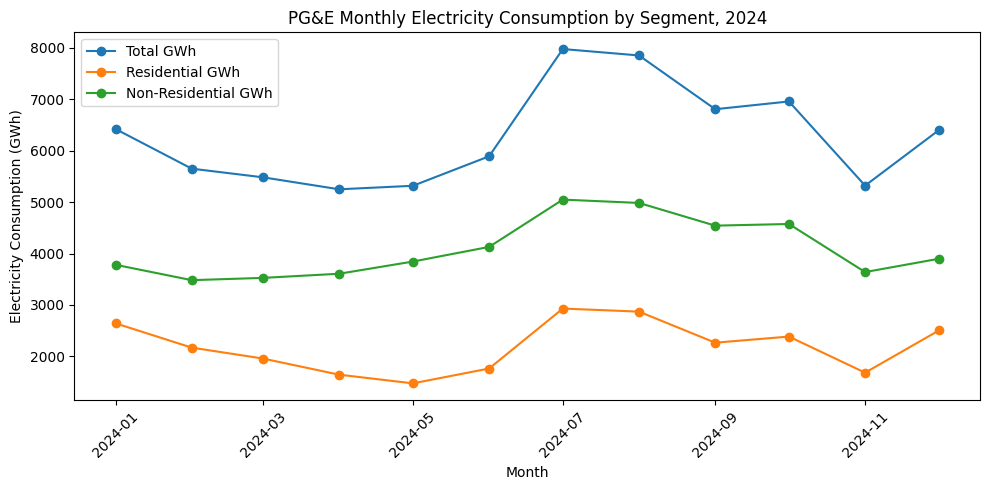

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    pge_monthly_2024["month_start_date"],
    pge_monthly_2024["total_gwh"],
    marker="o",
    label="Total GWh"
)
plt.plot(
    pge_monthly_2024["month_start_date"],
    pge_monthly_2024["residential_gwh"],
    marker="o",
    label="Residential GWh"
)
plt.plot(
    pge_monthly_2024["month_start_date"],
    pge_monthly_2024["nonresidential_gwh"],
    marker="o",
    label="Non-Residential GWh"
)

plt.title("PG&E Monthly Electricity Consumption by Segment, 2024")
plt.xlabel("Month")
plt.ylabel("Electricity Consumption (GWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Consumption Visualization Findings

The monthly consumption chart shows that PG&E electricity usage has a clear seasonal pattern in 2024.

Key observations:

- Total electricity consumption peaks in July and remains elevated in August.
- Non-residential consumption is consistently higher than residential consumption across the year.
- Residential consumption rises during the summer months and again in December, suggesting seasonal demand patterns.
- Spring months show lower total consumption compared with summer and winter.
- This seasonality should be reflected in the synthetic Meter-to-Cash billing layer so that generated meter reads and bill amounts follow realistic monthly usage patterns.

## 18. Export Processed Analysis Tables

This section exports the cleaned and analysis-ready tables created in this notebook. These files will be used in later notebooks, SQL modeling, and Power BI dashboard development.

In [30]:
# Define processed data directory
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Export cleaned and analysis-ready datasets
outage_county_clean.to_csv(PROCESSED_DIR / "outage_county_clean.csv", index=False)
outage_incidents_clean.to_csv(PROCESSED_DIR / "outage_incidents_clean.csv", index=False)
pge_outages.to_csv(PROCESSED_DIR / "pge_outage_incidents.csv", index=False)

utility_summary.to_csv(PROCESSED_DIR / "utility_outage_summary.csv", index=False)
pge_county_summary.to_csv(PROCESSED_DIR / "pge_county_outage_summary.csv", index=False)
pge_outage_type_summary.to_csv(PROCESSED_DIR / "pge_outage_type_summary.csv", index=False)
pge_cause_summary.to_csv(PROCESSED_DIR / "pge_cause_summary.csv", index=False)
pge_cause_category_summary.to_csv(PROCESSED_DIR / "pge_cause_category_summary.csv", index=False)

cec_county_monthly_summary.to_csv(PROCESSED_DIR / "cec_county_monthly_summary.csv", index=False)
county_consumption_latest_year.to_csv(PROCESSED_DIR / "county_consumption_2024.csv", index=False)
pge_county_outage_consumption.to_csv(PROCESSED_DIR / "pge_county_outage_consumption_context.csv", index=False)
pge_county_normalized_impact.to_csv(PROCESSED_DIR / "pge_county_normalized_impact.csv", index=False)

utility_consumption_latest_year.to_csv(PROCESSED_DIR / "utility_consumption_2024.csv", index=False)
pge_utility_sector_2024.to_csv(PROCESSED_DIR / "pge_utility_sector_2024.csv", index=False)
pge_monthly_2024.to_csv(PROCESSED_DIR / "pge_monthly_consumption_2024.csv", index=False)

# Confirm exported files
processed_files = sorted([file.name for file in PROCESSED_DIR.iterdir()])
processed_files

['cec_county_monthly_summary.csv',
 'county_consumption_2024.csv',
 'outage_county_clean.csv',
 'outage_incidents_clean.csv',
 'pge_cause_category_summary.csv',
 'pge_cause_summary.csv',
 'pge_county_normalized_impact.csv',
 'pge_county_outage_consumption_context.csv',
 'pge_county_outage_summary.csv',
 'pge_monthly_consumption_2024.csv',
 'pge_outage_incidents.csv',
 'pge_outage_type_summary.csv',
 'pge_utility_sector_2024.csv',
 'utility_consumption_2024.csv',
 'utility_outage_summary.csv']

### Processed Data Export Summary

The first notebook successfully created and exported a processed data layer for the project.

The exported files include:

- Cleaned outage county and outage incident datasets.
- PG&E-specific outage incident data.
- Utility-level and PG&E-specific outage summary tables.
- PG&E outage summaries by county, outage type, cause, and business-friendly cause category.
- County electricity consumption summaries using 2024 CEC data.
- Joined outage and electricity consumption context tables.
- PG&E utility-level sector and monthly consumption summaries.

These processed datasets will be used in later project stages for SQL modeling, Power BI dashboard development, and the synthetic Meter-to-Cash billing layer.

## 19. Notebook Summary and Next Steps

This notebook established the real-data foundation for the utility operations and Meter-to-Cash analytics project.

Key outcomes:

- Loaded and profiled real California outage and electricity consumption datasets.
- Standardized column names and cleaned key date, text, and categorical fields.
- Created a PG&E-specific outage incident subset.
- Summarized outage activity by utility, county, outage type, cause, and business-friendly cause category.
- Joined PG&E county outage impact to 2024 county electricity consumption data.
- Identified differences between raw outage impact and normalized outage impact.
- Summarized PG&E 2024 electricity consumption by utility sector and month.
- Exported analysis-ready processed CSV files for use in future notebooks and dashboard development.

The next notebook will focus on designing the Meter-to-Cash data model. It will use the real PG&E consumption patterns from this notebook to guide the creation of synthetic customer accounts, meters, meter reads, rate plans, bills, and billing exceptions.